In [78]:
import warnings
warnings.filterwarnings("ignore")
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline
from sklearn.datasets import load_wine
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
from sklearn.inspection import partial_dependence, PartialDependenceDisplay
from pycebox.ice import ice, ice_plot
from sklearn.inspection import permutation_importance
from xgboost import XGBClassifier, plot_importance

import shap
shap.initjs()

from lime import lime_tabular

def predict_proba_with_names(x):
    x_df = pd.DataFrame(x, columns=X_test.columns.tolist())
    return pipeline_rf.predict_proba(x_df)

In [53]:
data = load_wine()
X, y = data.data, data.target
feature_names = data.feature_names
class_names = data.target_names

X , y = pd.DataFrame(X, columns=feature_names), pd.Series(y)

In [54]:
X.head()

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0


<Axes: >

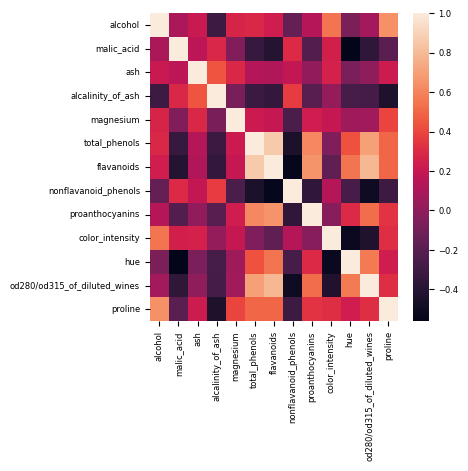

In [55]:
plt.rcParams['figure.figsize'] = (4, 4)
sns.heatmap(X.corr('pearson'))

In [56]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=True, random_state=42, stratify=y)

In [103]:
pipeline_rf = Pipeline(
    steps=[
        ("classifier", RandomForestClassifier(random_state=42))
    ]
)

pipeline_xgb = Pipeline(
    steps=[
        ("classifier", XGBClassifier())
    ]
)

pipeline_rf.fit(X_train, y_train)

pipeline_xgb.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'multi:softprob'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None


In [58]:
print(classification_report(y_test, pipeline_rf.predict(X_test)))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        12
           1       1.00      1.00      1.00        14
           2       1.00      1.00      1.00        10

    accuracy                           1.00        36
   macro avg       1.00      1.00      1.00        36
weighted avg       1.00      1.00      1.00        36



In [104]:
print(classification_report(y_test, pipeline_xgb.predict(X_test)))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        12
           1       1.00      1.00      1.00        14
           2       1.00      1.00      1.00        10

    accuracy                           1.00        36
   macro avg       1.00      1.00      1.00        36
weighted avg       1.00      1.00      1.00        36



#### Shap explainer

In [59]:
explainer = shap.Explainer(pipeline_rf[-1], X_test)
shap_values = explainer(X_test) # explainer(X_test).shap_values(X_test)

In [60]:
print(shap_values.shape)

(36, 13, 3)


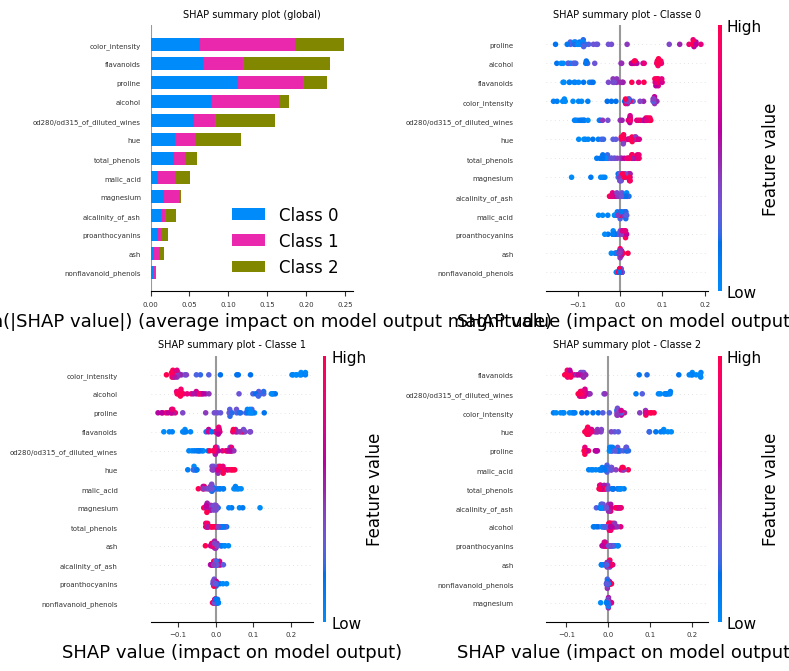

In [61]:
# ax = plt.subplot(2, 2, 1)
# shap.summary_plot(shap_values, X_test, plot_type="bar")
plt.rcParams["figure.figsize"] = (7, 20)
import matplotlib.pyplot as plt

plt.rcParams["figure.figsize"] = (7, 20)
plt.rcParams["font.size"] = 6  # Taille de police par défaut

class_names = pipeline_rf[-1].classes_

for i, class_name in enumerate(class_names):
    if i == 1:  # summary plot global
        ax = plt.subplot(2, 2, 1)
        shap.summary_plot(shap_values, X_test, plot_type="bar", show=False)

        ax = plt.gca()
        ax.set_title("SHAP summary plot (global)", fontsize=7)
        ax.tick_params(axis='y', labelsize=5)  # noms des features
        ax.tick_params(axis='x', labelsize=5)

    ax = plt.subplot(2, 2, i + 2)
    shap.summary_plot(shap_values[:, :, i], X_test, show=False)

    ax = plt.gca()
    ax.set_title(f"SHAP summary plot - Classe {class_name}", fontsize=7)
    ax.tick_params(axis='y', labelsize=5)  # noms des features
    ax.tick_params(axis='x', labelsize=5)

plt.tight_layout()
plt.show()

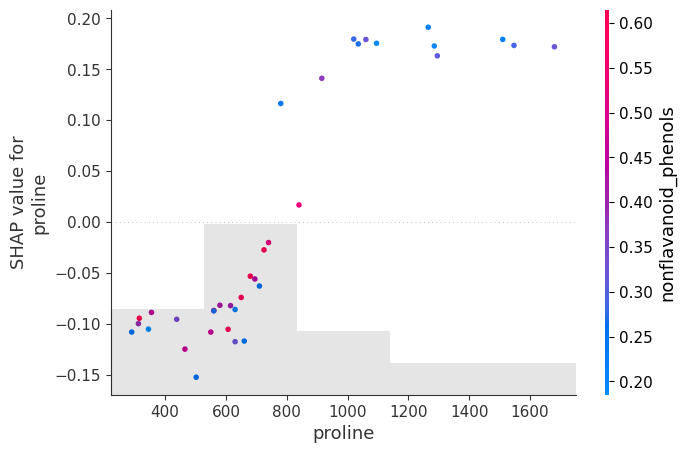

In [70]:
plt.rcParams["figure.figsize"] = (7, 7)
# Dépendance plot
# shap.dependence_plot("Subscription Length", shap_values[0], X_test,interaction_index="Age")

class_idx = 0  # la classe qui vous intéresse (0, 1 ou 2)

shap.plots.scatter(shap_values[:, "proline", class_idx], color=shap_values[:, :, class_idx])

In [71]:
i = 0          # index de l'observation à expliquer
class_idx = 0  # classe à expliquer (0, 1 ou 2)

shap.plots.force(shap_values[i, :, class_idx])

In [72]:
class_idx = 1

shap.plots.force(shap_values[i, :, class_idx])

In [73]:
class_idx = 2

shap.plots.force(shap_values[i, :, class_idx])

In [74]:
class_idx = 0  # la classe à visualiser

shap.plots.force(
    explainer.expected_value[class_idx],
    shap_values.values[:, :, class_idx],
    X_test
)

In [75]:
class_idx = 1  # la classe à visualiser

shap.plots.force(
    explainer.expected_value[class_idx],
    shap_values.values[:, :, class_idx],
    X_test
)

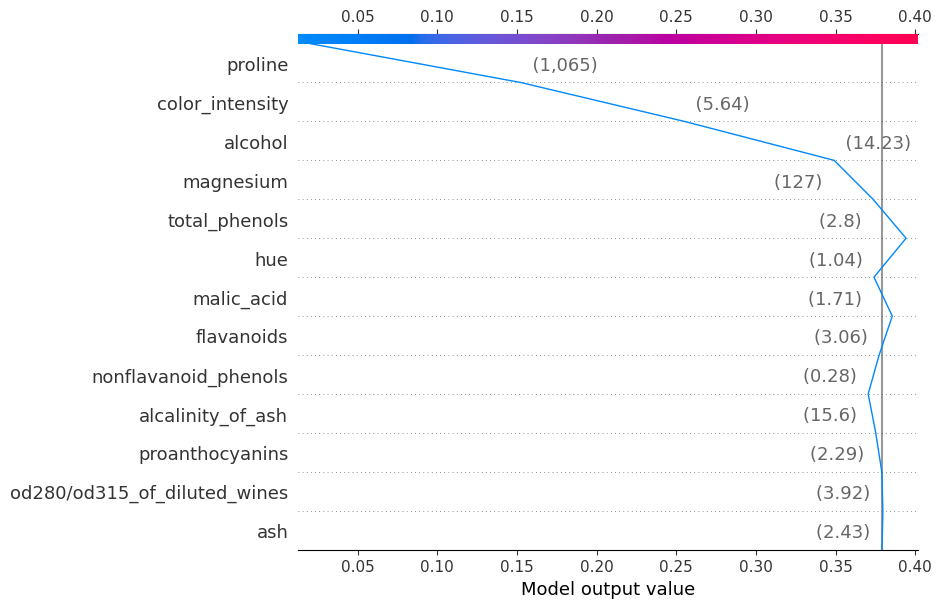

In [76]:
class_idx = 1
i = 0

shap.decision_plot(
    explainer.expected_value[class_idx],   # base value pour cette classe
    shap_values.values[i, :, class_idx],   # SHAP values pour cette observation
    X.iloc[i, :],                          # valeurs réelles des variables
    feature_names=feature_names
)

#### MDI

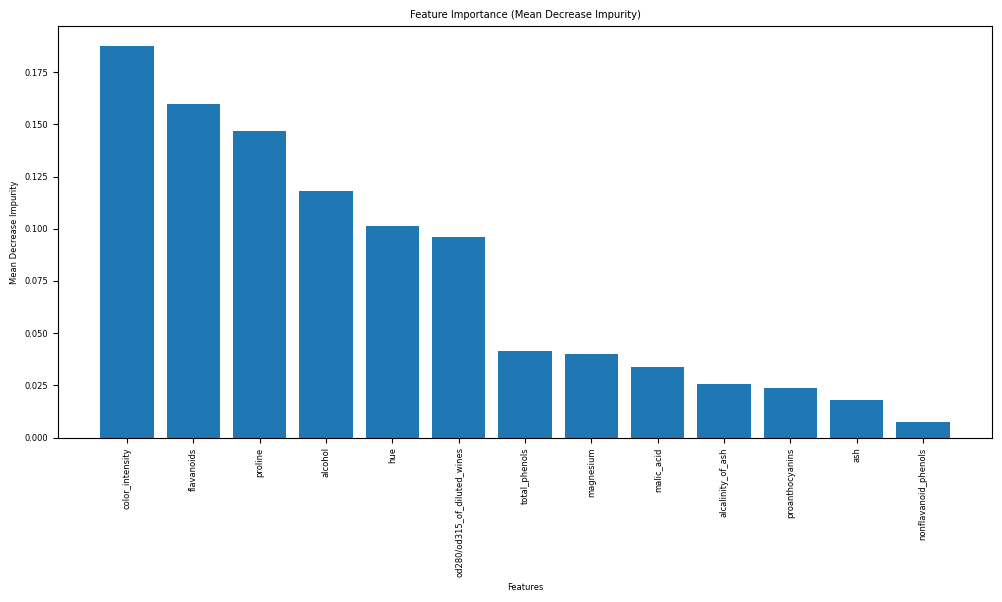

In [114]:

plt.rcParams["figure.figsize"] = (3, 3)

# Feature importances from a trained Random Forest model
importance = pipeline_rf[-1].feature_importances_

# Create a DataFrame
feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Mean Decrease Impurity': importance
})

# Sort by importance
feature_importance = feature_importance.sort_values(
    by='Mean Decrease Impurity',
    ascending=False
)

# Plot
plt.figure(figsize=(10, 6))
plt.bar(
    feature_importance['Feature'],
    feature_importance['Mean Decrease Impurity']
)
plt.xticks(rotation=90)
plt.xlabel('Features')
plt.ylabel('Mean Decrease Impurity')
plt.title('Feature Importance (Mean Decrease Impurity)')
plt.tight_layout()
plt.show()

#### Partial Dependence Plots (PDPs)

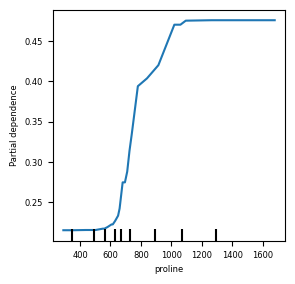

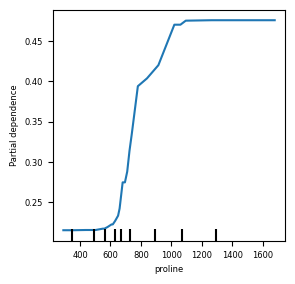

In [93]:
# Calculer la dépendance partielle
pdp_goals, axes = partial_dependence(pipeline_rf, X_test, features=['proline'])

# Créer le display
display = PartialDependenceDisplay.from_estimator(
    pipeline_rf,
    X_test,
    features=['proline'],
    target=0
)

# Afficher le graphique
display.plot()

#### Individual Conditional Expectation (ICE) plot

<Axes: >

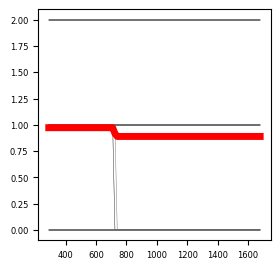

In [95]:
ice_df = ice(data=X_test, column='proline', predict=pipeline_rf.predict)
ice_plot(ice_df, c='dimgray', linewidth=0.3, plot_pdp=True, pdp_kwargs={'c': 'red', 'linewidth': 5})

#### Lime explainer

In [96]:
explainer_lime = lime_tabular.LimeTabularExplainer(
    X_train.values,
    feature_names=X_train.columns.tolist(),
    class_names=pipeline_rf.classes_.tolist(),
    verbose=True,
    mode="classification"
)

sample_idx = 1

exp = explainer_lime.explain_instance(X_test.values[sample_idx], pipeline_rf.predict_proba, num_features=X_test.shape[1])

# exp.show_in_notebook(show_table=True)

html = exp.as_html(show_table=True)
HTML(html)

Intercept 0.5406393882009707
Prediction_local [0.41974961]
Right: 0.23
